# Week 3: Unsupervised Learning and Clustering Analysis
## Global Well-being Segmentation using the World Happiness Report 2024

This notebook implements preprocessing, K-Means clustering, hierarchical clustering, validation, PCA visualization, and cluster interpretation. It is designed for **Jupyter Notebook** and uses a local `WHR2024.csv` file in the same folder.

### 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

pd.set_option('display.max_columns', None)


### 2. Load the public dataset

In [2]:
df = pd.read_csv('WHR2024.csv')
df.head()

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,Western Europe,7.741,1.844,1.572,0.695,0.859,0.142,0.546
1,Denmark,Western Europe,7.583,1.908,1.520,0.699,0.823,0.204,0.548
2,Iceland,Western Europe,7.525,1.881,1.617,0.718,0.819,0.258,0.182
3,Sweden,Western Europe,7.344,1.878,1.501,0.724,0.838,0.221,0.524
4,Israel,Middle East and North Africa,7.341,1.803,1.513,0.740,0.641,0.153,0.193


In [3]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nMissing values:\n', df.isna().sum())

Shape: (143, 9)

Columns: ['country', 'region', 'happiness_score', 'gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption']

Missing values:
 country                         0
region                          7
happiness_score                 0
gdp_per_capita                  3
social_support                  3
healthy_life_expectancy         3
freedom_to_make_life_choices    3
generosity                      3
perceptions_of_corruption       3
dtype: int64


### 3. Select clustering features and preprocess
The target-like `happiness_score` is retained for later interpretation but is not used to form the clusters. This avoids simply recreating the published happiness ranking. Four indicators contain a few impossible zero values in the supplied CSV; those zeroes are treated as missing before median imputation.

In [4]:
features = ['gdp_per_capita','social_support','healthy_life_expectancy',
            'freedom_to_make_life_choices','generosity','perceptions_of_corruption']

for c in ['gdp_per_capita','social_support','healthy_life_expectancy','freedom_to_make_life_choices']:
    df[c] = df[c].replace(0, np.nan)

for c in features:
    df[c] = df[c].fillna(df[c].median())

X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X.describe().round(3))

       gdp_per_capita  social_support  healthy_life_expectancy  \
count         143.000         143.000                  143.000   
mean            1.390           1.145                    0.525   
std             0.404           0.316                    0.157   
min             0.534           0.128                    0.156   
25%             1.086           0.940                    0.408   
50%             1.433           1.239                    0.550   
75%             1.733           1.377                    0.644   
max             2.141           1.617                    0.857   

       freedom_to_make_life_choices  generosity  perceptions_of_corruption  
count                       143.000     143.000                    143.000  
mean                          0.626       0.146                      0.153  
std                           0.152       0.073                      0.125  
min                           0.172       0.000                      0.000  
25%                 

### 4. Exploratory analysis

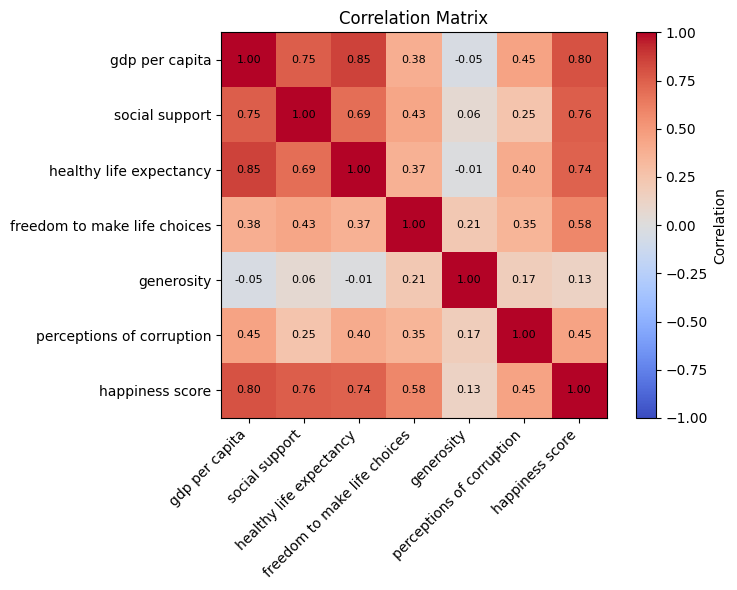

In [5]:
corr = df[features + ['happiness_score']].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr)), [c.replace('_',' ') for c in corr.columns], rotation=45, ha='right')
plt.yticks(range(len(corr)), [c.replace('_',' ') for c in corr.index])
plt.title('Correlation Matrix')
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 5. Choose the number of clusters

In [6]:
results = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = model.fit_predict(X_scaled)
    results.append({
        'k': k,
        'silhouette': silhouette_score(X_scaled, labels_k),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels_k),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels_k)
    })

metrics = pd.DataFrame(results)
metrics.round(3)

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.340,81.036,1.177
1,3,0.331,77.144,1.077
2,4,0.304,67.383,1.189
3,5,0.308,63.562,1.248
4,6,0.244,57.117,1.316
5,7,0.240,53.489,1.292
6,8,0.221,50.151,1.313


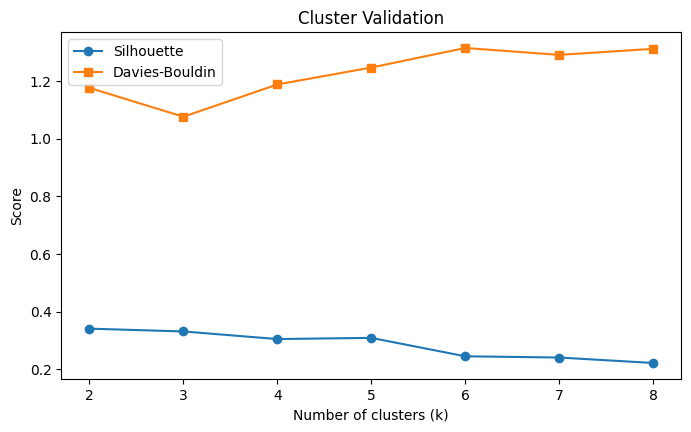

In [7]:
plt.figure(figsize=(8,4.5))
plt.plot(metrics['k'], metrics['silhouette'], marker='o', label='Silhouette')
plt.plot(metrics['k'], metrics['davies_bouldin'], marker='s', label='Davies-Bouldin')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Score')
plt.title('Cluster Validation')
plt.legend()
plt.show()

**Model choice:** k=2 has the best silhouette score, but k=3 has the lowest Davies-Bouldin value and provides a more informative three-tier segmentation. Therefore, k=3 is selected for the substantive analysis, with the k=2 result disclosed as a validation trade-off.

### 6. K-Means clustering

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

df['cluster'].value_counts().sort_index()

cluster
0    77
1    45
2    21
Name: count, dtype: int64

### 7. Hierarchical clustering

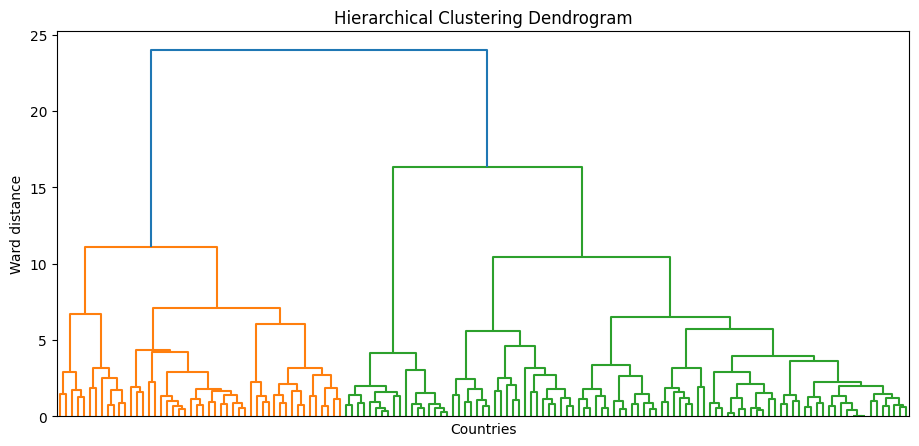

Adjusted Rand Index: 0.7368581135018621


In [9]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(11,5))
dendrogram(Z, no_labels=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Countries')
plt.ylabel('Ward distance')
plt.show()

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['hierarchical_cluster'] = hc.fit_predict(X_scaled)
print('Adjusted Rand Index:', adjusted_rand_score(df['cluster'], df['hierarchical_cluster']))

### 8. PCA visualization

Explained variance: [0.50938558 0.19492866]


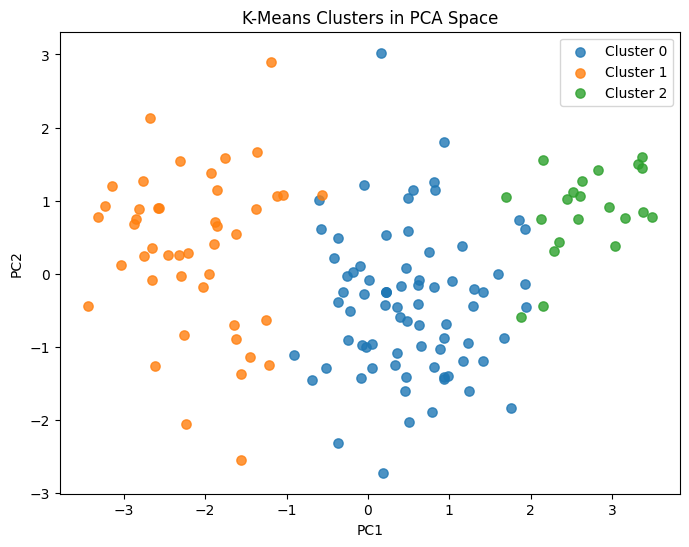

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PC1'], df['PC2'] = X_pca[:,0], X_pca[:,1]
print('Explained variance:', pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))
for c in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == c]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {c}', s=45, alpha=0.8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters in PCA Space')
plt.legend()
plt.show()

### 9. Interpret cluster characteristics

In [11]:
cluster_summary = df.groupby('cluster')[features + ['happiness_score']].mean().round(3)
cluster_summary

,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,happiness_score
cluster,,,,,,,
0,1.519,1.288,0.584,0.654,0.130,0.111,5.907
1,0.925,0.772,0.342,0.519,0.150,0.110,4.220
2,1.911,1.423,0.705,0.752,0.197,0.401,6.939


In [12]:
for c in sorted(df['cluster'].unique()):
    print(f'\nCluster {c}:')
    print(df[df['cluster']==c].sort_values('happiness_score', ascending=False)[['country','happiness_score']].head(10).to_string(index=False))


Cluster 0:
      country  happiness_score
       Israel            7.341
   Costa Rica            6.955
       Kuwait            6.951
      Czechia            6.822
    Lithuania            6.818
     Slovenia            6.743
United States            6.725
       Mexico            6.678
      Uruguay            6.611
 Saudi Arabia            6.594

Cluster 1:
            country  happiness_score
Congo (Brazzaville)            5.221
         Mozambique            5.216
               Iraq            5.166
              Nepal            5.158
               Laos            5.139
              Gabon            5.106
        Ivory Coast            5.080
             Guinea            5.023
            Senegal            4.969
            Nigeria            4.881

Cluster 2:
    country  happiness_score
    Finland            7.741
    Denmark            7.583
    Iceland            7.525
     Sweden            7.344
Netherlands            7.319
     Norway            7.302
 Luxembourg  

### 10. Final export

In [13]:
df.to_csv('WHR2024_clustered.csv', index=False)
cluster_summary.to_csv('cluster_summary.csv')
print('Saved clustered dataset and summary.')

Saved clustered dataset and summary.
